In [1]:
# Import libraries and set reproducibility
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from einops import rearrange, reduce
from IPython.display import display
from tqdm import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
# Download MNIST and create data loaders
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=512, shuffle=False, num_workers=0)
len(train_data), len(test_data)

(60000, 10000)

In [3]:
# Define convolution, activation, pooling, and linear tensor operations
def conv2d(x, weight, bias):
    kernel_size = weight.shape[-1]
    padding = kernel_size // 2
    x = torch.nn.functional.pad(x, (padding, padding, padding, padding))
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    output = torch.einsum(
        "b c h w i j, o c i j -> b o h w", patches, weight
    )
    return output + rearrange(bias, "o -> 1 o 1 1")


def linear(x, weight, bias):
    return torch.einsum("b i, o i -> b o", x, weight) + rearrange(bias, "o -> 1 o")


def relu(x):
    return x * (x > 0)


def max_pool_2x2(x):
    x = rearrange(x, "b c (h ph) (w pw) -> b c h w ph pw", ph=2, pw=2)
    return reduce(x, "b c h w ph pw -> b c h w", "max")

In [4]:
# Initialize trainable tensors and build the three-layer computation
def weight_tensor(shape, fan_in):
    return (torch.randn(shape, device=device) * (2 / fan_in) ** 0.5).requires_grad_()


parameters = {
    "conv1_w": weight_tensor((8, 1, 3, 3), 1 * 3 * 3),
    "conv1_b": torch.zeros(8, device=device, requires_grad=True),
    "conv2_w": weight_tensor((16, 8, 3, 3), 8 * 3 * 3),
    "conv2_b": torch.zeros(16, device=device, requires_grad=True),
    "conv3_w": weight_tensor((32, 16, 3, 3), 16 * 3 * 3),
    "conv3_b": torch.zeros(32, device=device, requires_grad=True),
    "linear_w": weight_tensor((10, 32 * 7 * 7), 32 * 7 * 7),
    "linear_b": torch.zeros(10, device=device, requires_grad=True),
}


def forward(x):
    x = max_pool_2x2(relu(conv2d(x, parameters["conv1_w"], parameters["conv1_b"])))
    x = max_pool_2x2(relu(conv2d(x, parameters["conv2_w"], parameters["conv2_b"])))
    x = relu(conv2d(x, parameters["conv3_w"], parameters["conv3_b"]))
    x = rearrange(x, "b c h w -> b (c h w)")
    return linear(x, parameters["linear_w"], parameters["linear_b"])

architecture = """CNN architecture
Input                 1 x 28 x 28
Conv1 + ReLU          8 x 28 x 28
MaxPool 2x2           8 x 14 x 14
Conv2 + ReLU         16 x 14 x 14
MaxPool 2x2          16 x 7 x 7
Conv3 + ReLU         32 x 7 x 7
Flatten                    1,568
Linear                       10"""
print(architecture)
print(f"Parameters: {sum(t.numel() for t in parameters.values()):,}")

CNN architecture
Input                 1 x 28 x 28
Conv1 + ReLU          8 x 28 x 28
MaxPool 2x2           8 x 14 x 14
Conv2 + ReLU         16 x 14 x 14
MaxPool 2x2          16 x 7 x 7
Conv3 + ReLU         32 x 7 x 7
Flatten                    1,568
Linear                       10
Parameters: 21,578


In [5]:
# Define cross-entropy loss and optimizer
def cross_entropy(logits, targets):
    log_probs = logits - torch.logsumexp(logits, dim=1, keepdim=True)
    one_hot = torch.nn.functional.one_hot(targets, num_classes=10).float()
    return -reduce(one_hot * log_probs, "b c ->", "sum") / logits.shape[0]


optimizer = torch.optim.Adam(parameters.values(), lr=1e-3)

In [6]:
# Train the CNN for five epochs
history = []
training_start = time.perf_counter()
for epoch in range(1, 6):
    total_loss = 0.0
    train_correct = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/5"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = forward(images)
        loss = cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        train_correct += torch.einsum("b ->", (logits.argmax(dim=1) == labels).float()).item()
    epoch_loss = total_loss / len(train_data)
    train_accuracy = 100 * train_correct / len(train_data)
    history.append((epoch_loss, train_accuracy))
    print(f"Epoch {epoch}: loss = {epoch_loss:.4f}, training accuracy = {train_accuracy:.2f}%")
total_training_time = time.perf_counter() - training_start
print(f"Total training time: {total_training_time:.2f} seconds")

Epoch 1/5:   0%|          | 0/235 [00:00<?, ?it/s]

Epoch 1/5:   0%|          | 1/235 [00:00<02:04,  1.87it/s]

Epoch 1/5:   2%|▏         | 4/235 [00:00<00:30,  7.54it/s]

Epoch 1/5:   3%|▎         | 7/235 [00:00<00:18, 12.26it/s]

Epoch 1/5:   4%|▍         | 10/235 [00:00<00:13, 16.10it/s]

...

Epoch 5/5:  97%|█████████▋| 228/235 [00:08<00:00, 27.36it/s]

Epoch 5/5:  98%|█████████▊| 231/235 [00:08<00:00, 27.24it/s]

Epoch 5/5: 100%|█████████▉| 234/235 [00:08<00:00, 27.22it/s]

Epoch 5/5: 100%|██████████| 235/235 [00:08<00:00, 27.01it/s]

Epoch 5: loss = 0.0387, training accuracy = 98.78%
Total training time: 44.38 seconds


In [7]:
# Evaluate accuracy on the MNIST test split
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predictions = forward(images).argmax(dim=1)
        correct += torch.einsum("b ->", (predictions == labels).float()).item()

test_accuracy = 100 * correct / len(test_data)
print(f"Test accuracy after 5 epochs: {test_accuracy:.2f}%")

Test accuracy after 5 epochs: 98.28%


In [8]:
# Sample 16 test images and predict their labels
generator = torch.Generator().manual_seed(seed)
sample_indices = torch.randperm(len(test_data), generator=generator)[:16]
sample_images = torch.stack([test_data[i][0] for i in sample_indices]).to(device)
sample_labels = torch.tensor([test_data[i][1] for i in sample_indices])

with torch.no_grad():
    sample_predictions = forward(sample_images).argmax(dim=1).cpu()

Dataset split: 60,000 training images, 10,000 test images
Test accuracy after 5 epochs: 98.28% (9,828 / 10,000 correct)
Training accuracy after 5 epochs: 98.78%
Total training time: 44.38 seconds
Architecture: Conv(1->8, 3x3) -> ReLU -> MaxPool(2x2) -> Conv(8->16, 3x3) -> ReLU -> MaxPool(2x2) -> Conv(16->32, 3x3) -> ReLU -> Flatten(1,568) -> 10 classes
Convolution settings: stride=1, padding=1
Parameters: 21,578
Execution device: NVIDIA A100-SXM4-40GB



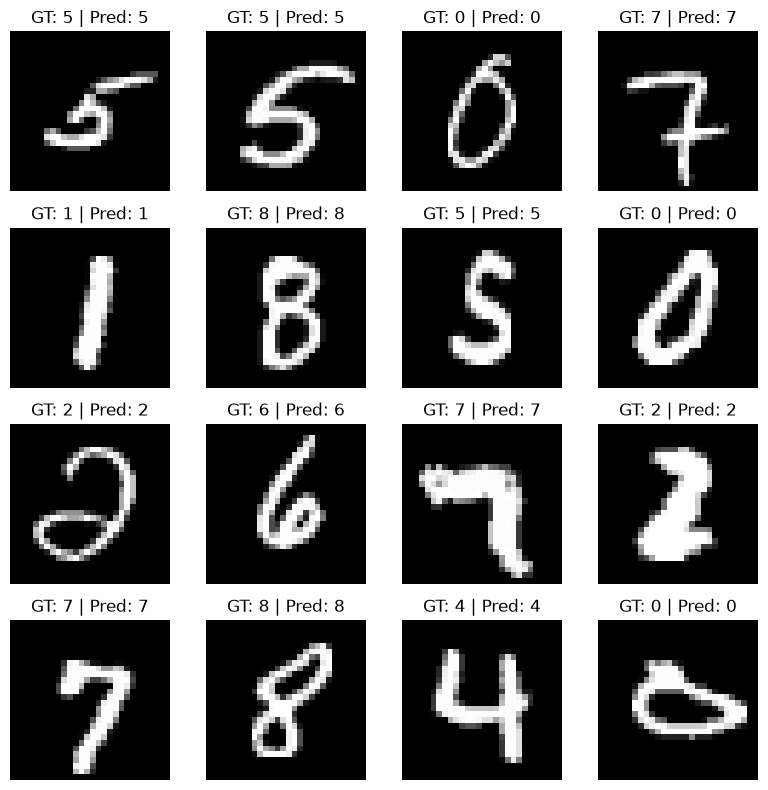

In [9]:
# Display the final summary and sample predictions
device_name = torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU"
print(f"Dataset split: {len(train_data):,} training images, {len(test_data):,} test images")
print(f"Test accuracy after 5 epochs: {test_accuracy:.2f}% ({int(correct):,} / {len(test_data):,} correct)")
print(f"Training accuracy after 5 epochs: {train_accuracy:.2f}%")
print(f"Total training time: {total_training_time:.2f} seconds")
print("Architecture: Conv(1->8, 3x3) -> ReLU -> MaxPool(2x2) -> "
      "Conv(8->16, 3x3) -> ReLU -> MaxPool(2x2) -> "
      "Conv(16->32, 3x3) -> ReLU -> Flatten(1,568) -> 10 classes")
print("Convolution settings: stride=1, padding=1")
print(f"Parameters: {sum(t.numel() for t in parameters.values()):,}")
print(f"Execution device: {device_name}")
print()
images_to_plot = rearrange(sample_images.cpu(), "b 1 h w -> b h w")
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for image, gt, pred, ax in zip(images_to_plot, sample_labels, sample_predictions, axes.flat):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"GT: {gt.item()} | Pred: {pred.item()}")
    ax.axis("off")
plt.tight_layout()
display(fig)
plt.close(fig)